In [2]:
# Install the Python package (works everywhere in notebooks)
%pip install -q diagrams

# Ensure Graphviz binary ("dot") is available
import os, sys, shutil, subprocess
from IPython.display import Markdown, display

def sh(cmd):
    print(f"$ {cmd}")
    return subprocess.run(cmd, shell=True, check=False)

if shutil.which("dot") is None:
    print("Graphviz 'dot' not found. Attempting installation…")
    # If this is a conda env, try conda first
    if shutil.which("conda"):
        rc = sh("conda install -y -c conda-forge graphviz")
        if rc.returncode == 0 and shutil.which("dot"):
            print("Graphviz installed via conda.")
    # If still missing, try OS-specific hints/installs
    if shutil.which("dot") is None:
        if sys.platform.startswith("linux"):
            sh("sudo apt-get update && sudo apt-get install -y graphviz || (apt-get update && apt-get install -y graphviz)")
        elif sys.platform == "darwin":
            display(Markdown("**macOS:** Open Terminal and run: `brew install graphviz`"))
        elif sys.platform.startswith("win"):
            display(Markdown("**Windows:** Open *Administrator* PowerShell and run: `choco install graphviz -y`"))
        else:
            display(Markdown("Install Graphviz from https://graphviz.org/download/"))

# Final check (will raise if still missing)
assert shutil.which("dot"), "Graphviz is not installed; follow the message above, then re-run this cell."
print("All good: 'dot' found at", shutil.which("dot"))


Note: you may need to restart the kernel to use updated packages.
Graphviz 'dot' not found. Attempting installation…
$ sudo apt-get update && sudo apt-get install -y graphviz || (apt-get update && apt-get install -y graphviz)


/bin/sh: 1: sudo: not found


Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy InRelease [270 kB]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1581 B]
Get:4 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:5 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy/main amd64 Packages [33.2 kB]
Get:6 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1274 kB]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 http://security.ubuntu.com/ubuntu jammy-security/multiverse amd64 Packages [80.3 kB]
Get:9 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [5441 kB]
Get:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy/main amd64 Packages [1792 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3311 k

debconf: delaying package configuration, since apt-utils is not installed


Fetched 9880 kB in 4s (2812 kB/s)
Selecting previously unselected package libfribidi0:amd64.
(Reading database ... 22600 files and directories currently installed.)
Preparing to unpack .../00-libfribidi0_1.0.8-2ubuntu3.1_amd64.deb ...
Unpacking libfribidi0:amd64 (1.0.8-2ubuntu3.1) ...
Selecting previously unselected package libpng16-16:amd64.
Preparing to unpack .../01-libpng16-16_1.6.37-3build5_amd64.deb ...
Unpacking libpng16-16:amd64 (1.6.37-3build5) ...
Selecting previously unselected package libfreetype6:amd64.
Preparing to unpack .../02-libfreetype6_2.11.1+dfsg-1ubuntu0.3_amd64.deb ...
Unpacking libfreetype6:amd64 (2.11.1+dfsg-1ubuntu0.3) ...
Selecting previously unselected package fonts-dejavu-core.
Preparing to unpack .../03-fonts-dejavu-core_2.37-2build1_all.deb ...
Unpacking fonts-dejavu-core (2.37-2build1) ...
Selecting previously unselected package fonts-liberation.
Preparing to unpack .../04-fonts-liberation_1%3a1.07.4-11_all.deb ...
Unpacking fonts-liberation (1:1.07.4-11

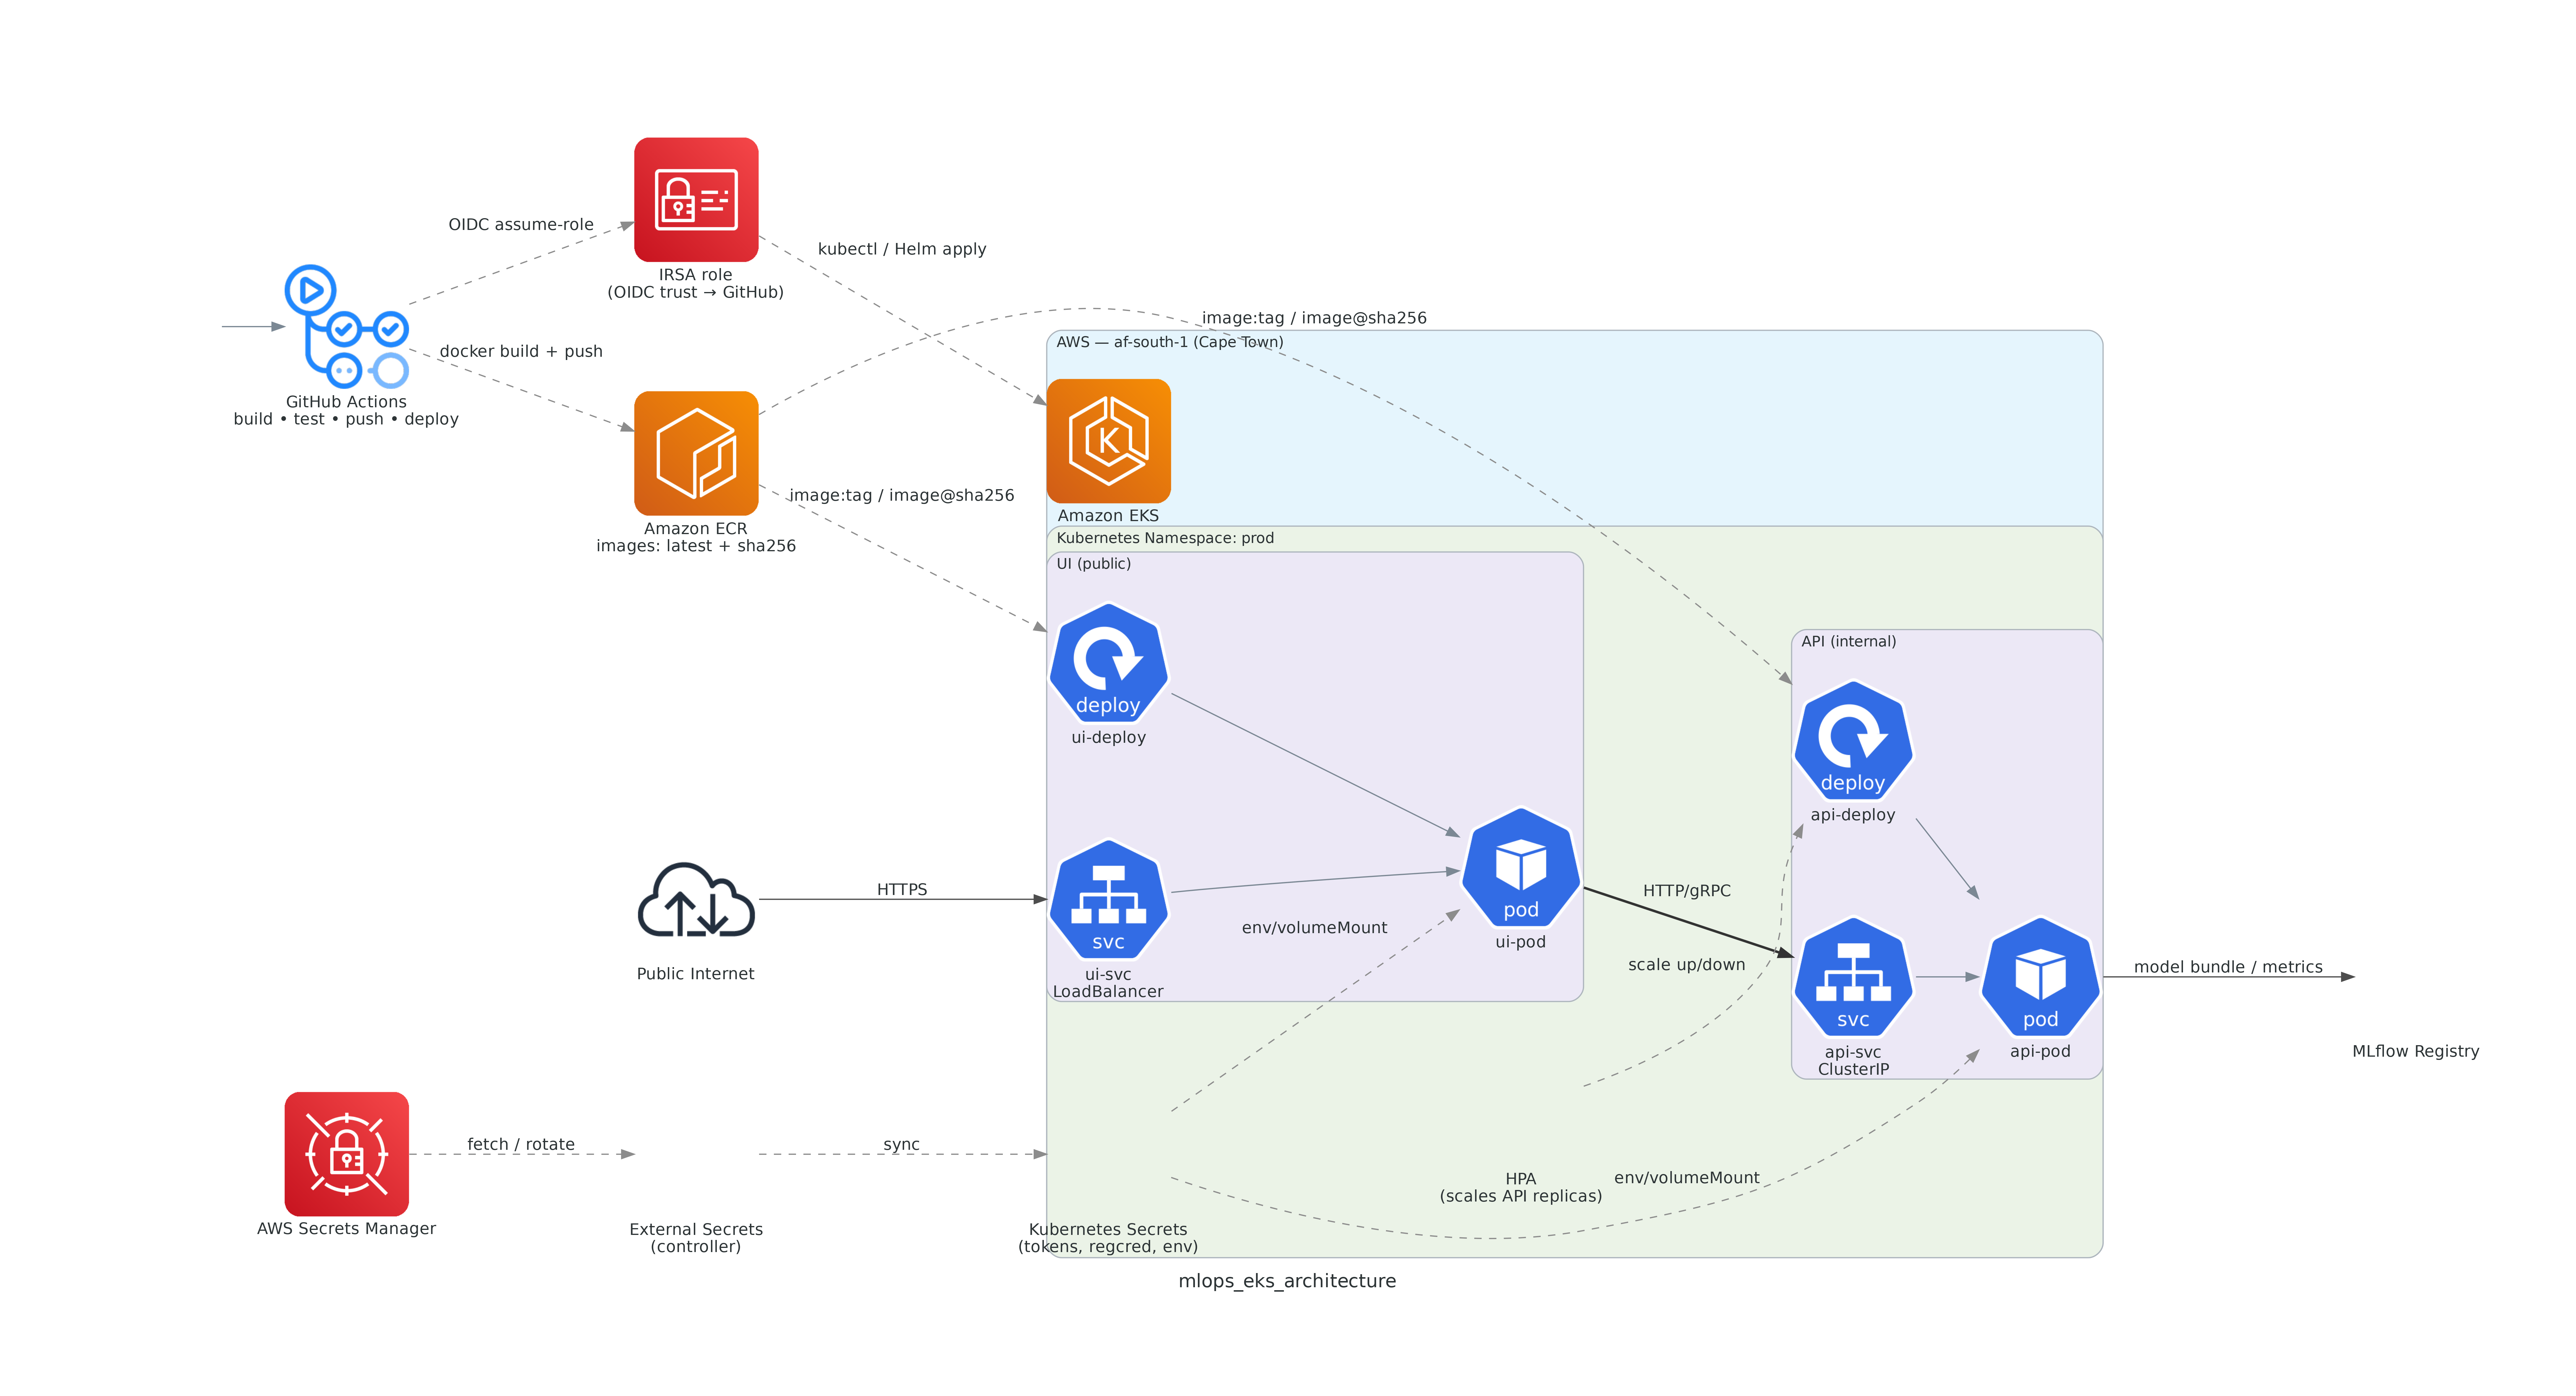

Saved: mlops_eks_architecture.png, mlops_eks_architecture.pdf, mlops_eks_architecture.svg


In [5]:
# §3.5 Deployment pipeline & environment — final polished AWS/EKS diagram (notebook cell)

from diagrams import Diagram, Cluster, Edge
from diagrams.aws.compute import EKS, ECR
from diagrams.aws.security import IAM, SecretsManager
from diagrams.onprem.ci import GithubActions
from diagrams.onprem.network import Internet
from diagrams.k8s.compute import Deployment, Pod
from diagrams.k8s.network import Service
from diagrams.generic.blank import Blank
from IPython.display import Image, display

# Robust icon imports across diagrams versions
try:
    from diagrams.onprem.mlops import MLflow as MLflowNode
except Exception:
    try:
        from diagrams.onprem.ml import Mlflow as MLflowNode
    except Exception:
        MLflowNode = Blank  # fallback: labeled box

try:
    from diagrams.k8s.config import Secret as K8sSecret
except Exception:
    K8sSecret = Blank

GRAPH_ATTR = {
    # extra space so labels never clip at canvas edges
    "pad": "0.85",
    "margin": "0.25,0.25",
    "splines": "spline",
    "nodesep": "0.55",
    "ranksep": "0.70",
    "dpi": "300",
    "bgcolor": "white",
}

# Edge styles
DATA_EDGE   = dict(color="gray30", style="solid",  minlen="1")
CTRL_EDGE   = dict(color="gray55", style="dashed", minlen="1")
STRONG_EDGE = dict(color="gray20", style="bold",   minlen="1")

GHA_LABEL = "GitHub Actions\nbuild • test • push • deploy"

def render_mlops_eks_arch(filename="mlops_eks_architecture", outformat="png"):
    with Diagram(
        filename, show=False, outformat=outformat, direction="LR", graph_attr=GRAPH_ATTR
    ):
        # Invisible spacer nudges leftmost node inward (prevents label clipping)
        spacer = Blank(" ")

        # CI/CD, auth, registries, internet
        gha = GithubActions(GHA_LABEL)
        spacer >> gha  # push it a bit to the right

        iam = IAM("IRSA role\n(OIDC trust → GitHub)")
        ecr = ECR("Amazon ECR\nimages: latest + sha256")
        internet = Internet("Public Internet")
        sm = SecretsManager("AWS Secrets Manager")
        ext_secrets = Blank("External Secrets\n(controller)")
        mlflow = MLflowNode("MLflow Registry")

        # ---------------- AWS Region + EKS ----------------
        with Cluster("AWS — af-south-1 (Cape Town)"):
            eks = EKS("Amazon EKS")

            with Cluster("Kubernetes Namespace: prod"):
                # --- UI (public) ---
                with Cluster("UI (public)"):
                    ui_deploy = Deployment("ui-deploy")
                    ui_pod    = Pod("ui-pod")
                    ui_svc_lb = Service("ui-svc\nLoadBalancer")

                    ui_deploy >> ui_pod
                    internet >> Edge(label="HTTPS", **DATA_EDGE) >> ui_svc_lb >> ui_pod

                # --- API (internal) ---
                with Cluster("API (internal)"):
                    api_deploy = Deployment("api-deploy")
                    api_pod    = Pod("api-pod")
                    api_svc    = Service("api-svc\nClusterIP")

                    api_deploy >> api_pod
                    ui_pod >> Edge(label="HTTP/gRPC", **STRONG_EDGE) >> api_svc >> api_pod

                # --- Secrets + HPA ---
                k8s_secrets = K8sSecret("Kubernetes Secrets\n(tokens, regcred, env)")
                hpa = Blank("HPA\n(scales API replicas)")

                ext_secrets >> Edge(label="sync", **CTRL_EDGE) >> k8s_secrets
                k8s_secrets >> Edge(label="env/volumeMount", **CTRL_EDGE) >> ui_pod
                k8s_secrets >> Edge(label="env/volumeMount", **CTRL_EDGE) >> api_pod
                hpa >> Edge(label="scale up/down", **CTRL_EDGE) >> api_deploy

            # Image pulls into deployments
            ecr >> Edge(label="image:tag / image@sha256", **CTRL_EDGE) >> ui_deploy
            ecr >> Edge(label="image:tag / image@sha256", **CTRL_EDGE) >> api_deploy

            # Runtime model bundle / metrics
            api_pod >> Edge(label="model bundle / metrics", **DATA_EDGE) >> mlflow

        # CI/CD: auth + actions
        gha >> Edge(label="OIDC assume-role", **CTRL_EDGE) >> iam \
            >> Edge(label="kubectl / Helm apply", **CTRL_EDGE) >> eks
        gha >> Edge(label="docker build + push", **CTRL_EDGE) >> ecr

        # Secrets sync from AWS to cluster
        sm >> Edge(label="fetch / rotate", **CTRL_EDGE) >> ext_secrets

    return f"{filename}.{outformat}"

# Render and display
png_path = render_mlops_eks_arch(outformat="png")
pdf_path = render_mlops_eks_arch(outformat="pdf")
svg_path = render_mlops_eks_arch(outformat="svg")
display(Image(filename=png_path, width=1200))
print(f"Saved: {png_path}, {pdf_path}, {svg_path}")
